In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
class linear_SVM:
    def __init__(self,lambda_=0.01,epochs=1000,lr=0.01):
        self.lr = lr
        self.lambda_ = lambda_
        self.epochs = epochs
        self.w = None
        self.b = None
    
    def fit(self,x_train,y_train):
        m,n = x_train.shape
        self.w = np.zeros(n)
        self.b = 0
        x_train = np.array(x_train)
        y_train = np.array(y_train)

        for _ in range(self.epochs):
            for i in range(m):
                condition =  y_train[i]*(np.dot(self.w,x_train[i])+ self.b) >= 1
                if condition:
                    self.w -= self.lr*(2*self.lambda_*self.w)
                else:
                    self.w -= self.lr*((2*self.lambda_*self.w) - y_train[i]*x_train[i])
                    self.b += self.lr*y_train[i]

    def predict(self,x_test):
        x_test = np.array(x_test)
        y_pred = np.dot(x_test,self.w) + self.b
        return np.where(y_pred >= 0 , 1 ,-1)
        

    def coef(self):
        return self.w
    def intercept(self):
        return self.b        
    

In [3]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//linear_svm.csv")
df.head()

,feature_1,feature_2,target
0,2.740,4.086,1
1,-0.611,1.997,-1
2,3.586,-2.341,1
3,1.974,4.692,1
4,-4.058,2.788,-1


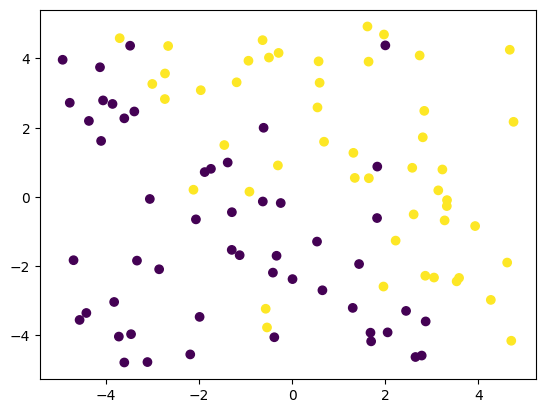

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df['feature_1'],df['feature_2'],c=df['target'])

In [5]:
x = df.drop(columns=['target'])
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
svm = linear_SVM(lr=0.01,epochs=1000,lambda_=0.01)
svm.fit(x_train,y_train)

print(f"w = {svm.coef()} and b = {svm.intercept()}")

w = [0.61077316 0.46960178] and b = -0.07


In [7]:
from sklearn.metrics import accuracy_score
y_pred = svm.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [8]:
from sklearn.svm import LinearSVC
svc = LinearSVC(max_iter=2000)
svc.fit(x_train,y_train)

print(f"w = {svc.coef_} and b = {svc.intercept_}")

w = [[0.24910081 0.21333798]] and b = [-0.00368911]


In [9]:
accuracy_score(svc.predict(x_test),y_test)

0.95

<Axes: >

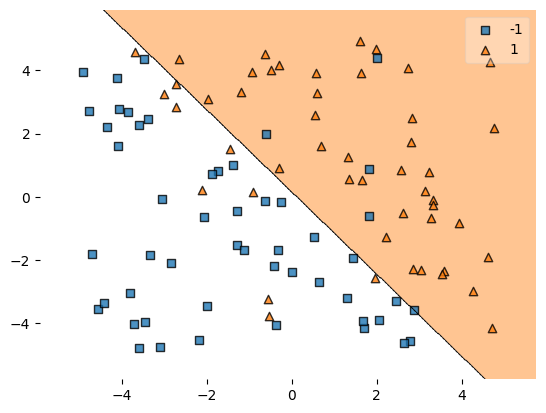

In [10]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X=np.array(x),y=np.array(y),clf=svm)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


<Axes: >

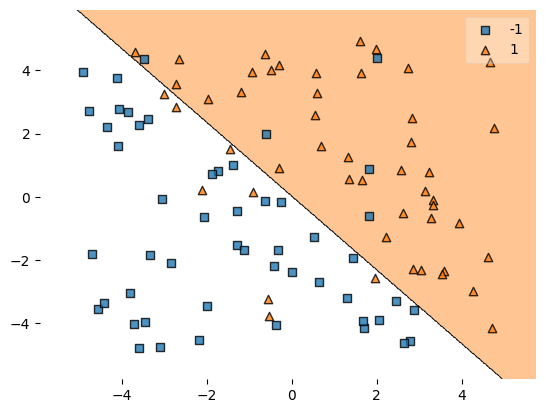

In [11]:
plot_decision_regions(X=np.array(x),y=np.array(y),clf=svc)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


<Axes: >

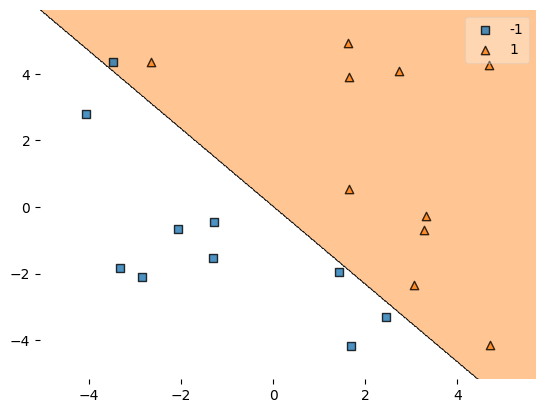

In [12]:
plot_decision_regions(X=np.array(x_test),y=np.array(y_test),clf=svc)

<Axes: >

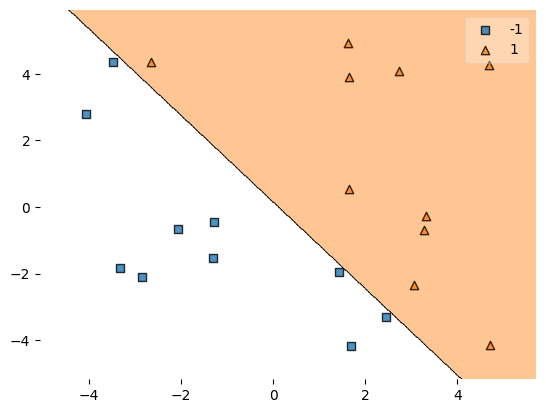

In [13]:
plot_decision_regions(X=np.array(x_test),y=np.array(y_test),clf=svm)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

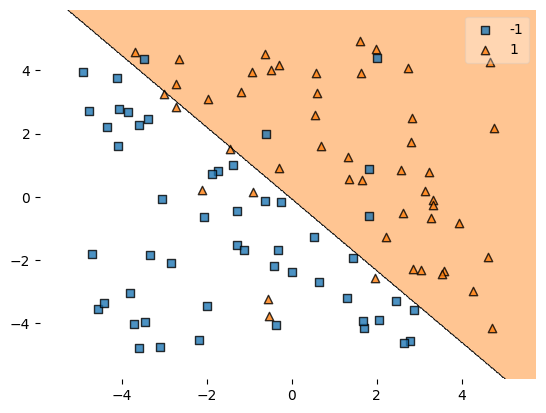

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

plot_decision_regions(X=np.array(x),y=np.array(y),clf=lr)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

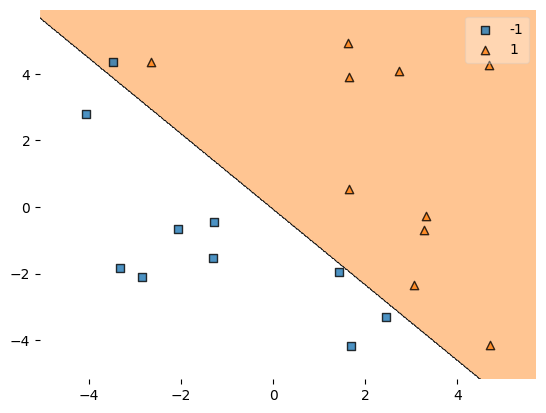

In [15]:
plot_decision_regions(X=np.array(x_test),y=np.array(y_test),clf=lr)